In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Tạo dữ liệu có nhiễu
rng = np.random.default_rng(42)

X = rng.uniform(-3, 3, size=(50, 1))
noise = rng.normal(loc=0, scale=1, size=50)

y = 0.5 * X[:, 0]**3 - 2 * X[:, 0]**2 + X[:, 0] + 3 + noise

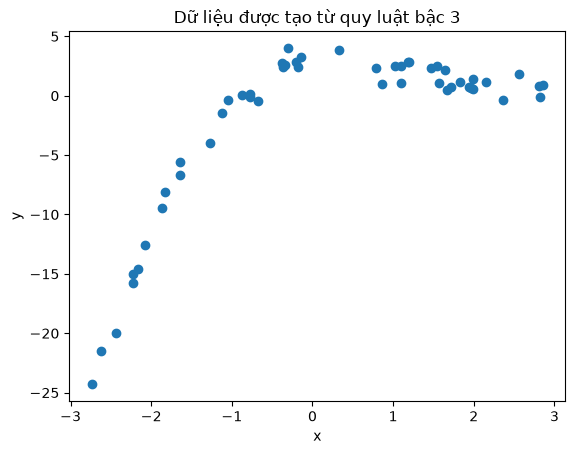

In [50]:
plt.scatter(X[:, 0], y)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Dữ liệu được tạo từ quy luật bậc 3")
plt.show()

In [51]:
# Chia dữ liệu thành tập huấn luyện và tập kiểm tra
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)

In [52]:
models = {
    "Baseline mean": DummyRegressor(strategy="mean"),

    # Chỉ dùng x → đường thẳng, có thể underfit
    "Linear degree 1": Pipeline([
        ("poly", PolynomialFeatures(degree=1, include_bias=False)),
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    # Dùng x, x², x³ → phù hợp với quy luật dữ liệu
    "Polynomial degree 3": Pipeline([
        ("poly", PolynomialFeatures(degree=3, include_bias=False)),
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    # Bậc cao → có nguy cơ overfit
    "Polynomial degree 10": Pipeline([
        ("poly", PolynomialFeatures(degree=10, include_bias=False)),
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    # Bậc cao nhưng có regularization L2
    "Degree 10 + Ridge": Pipeline([
        ("poly", PolynomialFeatures(degree=10, include_bias=False)),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=10.0))
    ])
}

In [53]:
results = []
test_predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    test_predictions[name] = test_pred

    results.append({
        "Model": name,
        "Train MAE": mean_absolute_error(y_train, train_pred),
        "Test MAE": mean_absolute_error(y_test, test_pred),
        "Train RMSE": mean_squared_error(y_train, train_pred) ** 0.5,
        "Test RMSE": mean_squared_error(y_test, test_pred) ** 0.5,
        "Train R²": r2_score(y_train, train_pred),
        "Test R²": r2_score(y_test, test_pred)
    })

results_df = pd.DataFrame(results).round(3)
results_df

,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R²,Test R²
0,Baseline mean,4.914,6.125,6.547,8.272,0.000,-0.006
1,Linear degree 1,3.832,3.997,4.693,5.427,0.486,0.567
2,Polynomial degree 3,0.561,0.784,0.685,0.935,0.989,0.987
3,Polynomial degree 10,0.478,0.784,0.586,1.048,0.992,0.984
4,Degree 10 + Ridge,1.219,1.091,1.544,1.432,0.944,0.970


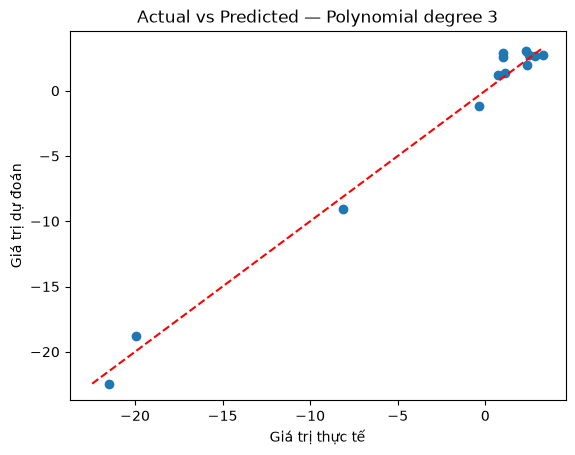

In [54]:
y_pred = test_predictions["Polynomial degree 3"]

low = min(y_test.min(), y_pred.min())
high = max(y_test.max(), y_pred.max())

plt.scatter(y_test, y_pred)
plt.plot([low, high], [low, high], "r--")
plt.xlabel("Giá trị thực tế")
plt.ylabel("Giá trị dự đoán")
plt.title("Actual vs Predicted — Polynomial degree 3")
plt.show()

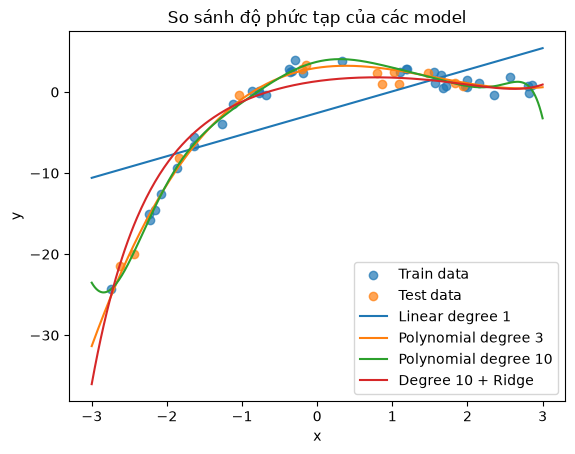

In [55]:
X_line = np.linspace(-3, 3, 300).reshape(-1, 1)

plt.scatter(X_train[:, 0], y_train, label="Train data", alpha=0.7)
plt.scatter(X_test[:, 0], y_test, label="Test data", alpha=0.7)

for name in [
    "Linear degree 1",
    "Polynomial degree 3",
    "Polynomial degree 10",
    "Degree 10 + Ridge"
]:
    plt.plot(X_line[:, 0], models[name].predict(X_line), label=name)

plt.xlabel("x")
plt.ylabel("y")
plt.title("So sánh độ phức tạp của các model")
plt.legend()
plt.show()

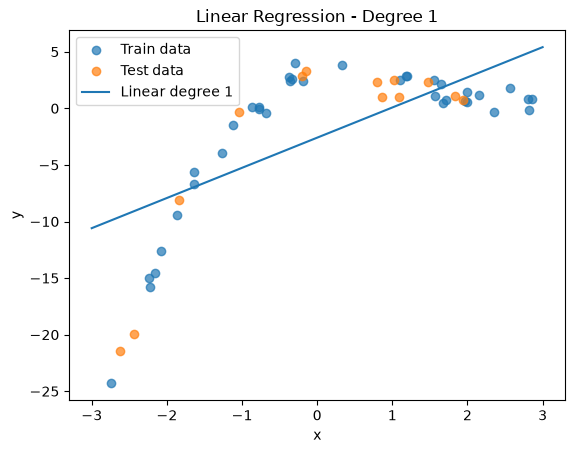

In [56]:
#Under Fit model
X_line = np.linspace(-3, 3, 300).reshape(-1,1)

# Vẽ dữ liệu
plt.scatter(X_train[:, 0], y_train, label="Train data", alpha=0.7)
plt.scatter(X_test[:, 0], y_test, label="Test data", alpha=0.7)

plt.plot(
    X_line[:,0],
    models["Linear degree 1"].predict(X_line),
    label="Linear degree 1"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear Regression - Degree 1")
plt.legend()
plt.show()

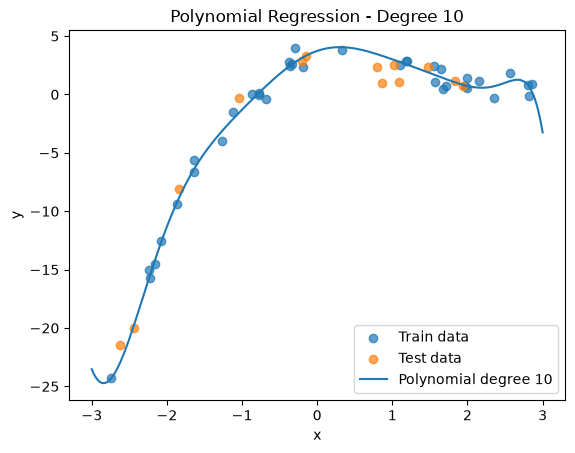

In [57]:
# OverFit model
X_line = np.linspace(-3, 3, 300).reshape(-1,1)

# Vẽ dữ liệu
plt.scatter(X_train[:, 0], y_train, label="Train data", alpha=0.7)
plt.scatter(X_test[:, 0], y_test, label="Test data", alpha=0.7)

plt.plot(
    X_line[:,0],
    models["Polynomial degree 10"].predict(X_line),
    label="Polynomial degree 10"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Polynomial Regression - Degree 10")
plt.legend()
plt.show()

In [58]:
error_df = pd.DataFrame({
    "x": X_test[:, 0],
    "actual": y_test,
    "predicted": y_pred,
    "abs_error": np.abs(y_test - y_pred)
})

worst_5 = error_df.sort_values("abs_error", ascending=False).head(5)
worst_5

,x,actual,predicted,abs_error
10,0.863191,1.011705,2.927383,1.915678
5,1.094973,1.030759,2.612803,1.582044
11,-2.434936,-19.968179,-18.786356,1.181823
4,-2.617096,-21.484638,-22.445545,0.960907
7,-1.832168,-8.123830,-9.074107,0.950277
